🎮 Akt 1: Die digitale Goldgräberstimmung
Analyse der globalen Videospiel-Evolution (1980 – Heute)
Der Kontext: Videospiele sind längst kein Nischenhobby mehr, sondern ein globaler Wirtschaftsfaktor, der Hollywood oft in den Schatten stellt. Mit diesem bereinigten Datensatz von 11.470 Spielen untersuchen wir nicht nur Verkaufszahlen, sondern kulturelle Verschiebungen.

Die Hauptdarsteller (Features):

Die Geografie des Erfolgs: Wie unterscheiden sich die Vorlieben zwischen Nordamerika (NA), Europa (EU) und Japan (JP)?

Die Plattform-Kriege: Wer dominierte die Hardware-Ära – Sony, Microsoft oder Nintendo?

Genre-Trends: Welche Kategorien sind zeitlose Megaseller und welche waren nur Eintagsfliegen?

Status-Check: Der Datensatz ist mit 0 Nullwerten und 0 Duplikaten perfekt vorbereitet. Wir können uns also direkt auf die Interpretation konzentrieren, ohne im "Data-Cleaning-Sumpf" zu versinken.

In [1]:
# --- 1. Standard-Bibliotheken ---
import os

# --- 2. Datenverarbeitung & Analyse ---
import numpy as np
import pandas as pd

# --- 3. Visualisierung ---
import matplotlib.pyplot as plt
import seaborn as sns

# Profi-Einstellung: Ein einheitliches Design für alle Grafiken im Projekt
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline 
# Stellt sicher, dass Plots direkt im Notebook angezeigt werden

# --- 4. Machine Learning & Preprocessing ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- 5. Projekt-Konfiguration (Pfade) ---
# Das macht deinen Code robust, egal auf welchem Rechner er läuft
INPUT_DIR = "00_Data_Sets"
OUTPUT_DIR = "00_Outputs"

# Sicherstellen, dass der Output-Ordner existiert
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
# 1. Pfade definieren
DATA_PATH = os.path.join("00_Data_Sets", "00_cleaned_global_video_game_sales.csv")
LOG_FILE = os.path.join("00_Outputs", "data_load_report.txt")

# 2. Laden & Kopieren
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy(deep=True)

# 3. Bericht erstellen und speichern
log_text = f"--- Daten-Lade-Bericht ---\n"
log_text += f"Datei: {DATA_PATH}\n"
log_text += f"Dimensionen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten\n"
log_text += "-" * 25 + "\n"

# Wir hängen die ersten 8 Zeilen der Tabelle als Text an den Bericht an
log_text += "Erste 8 Zeilen der Daten:\n"
log_text += df.head(8).to_string() 

# Den gesamten Text in eine Datei schreiben
with open(LOG_FILE, "w", encoding="utf-8") as f:
    f.write(log_text)

print(f"✅ Bericht wurde unter '{LOG_FILE}' gespeichert.")
df.head(8)

✅ Bericht wurde unter '00_Outputs\data_load_report.txt' gespeichert.


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon RedPokemon Blue,GB,1996,Role Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02


In [6]:
# --- 1. Pfad für den Qualitätsbericht ---
QUALITY_REPORT_PATH = os.path.join("00_Outputs", "data_quality_report.txt")

# --- 2. Analyse der fehlenden Werte ---
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Erstellen des DataFrames für den Bericht
null_report = pd.DataFrame({
    'Fehlende Werte (Absolut)': missing_values, 
    'Fehlende Werte (Prozent)': missing_percent
})

# Nur Spalten anzeigen, die tatsächlich Lücken haben (sortiert nach Relevanz)
bad_columns = null_report[null_report['Fehlende Werte (Absolut)'] > 0].sort_values(by='Fehlende Werte (Prozent)', ascending=False)

# --- 3. Den Bericht in eine Textdatei schreiben ---
with open(QUALITY_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write("=== DATENQUALITÄTS-ANALYSE ===\n\n")
    
    # Allgemeine Info (df.info() lässt sich nicht direkt als Text speichern, 
    # daher nutzen wir eine alternative Methode, um die Typen zu erfassen)
    f.write("--- Datentypen der Spalten ---\n")
    f.write(df.dtypes.to_string())
    f.write("\n\n")
    
    f.write("--- Fehlende Werte Analyse ---\n")
    if not bad_columns.empty:
        f.write(bad_columns.to_string())
    else:
        f.write("Keine fehlenden Werte gefunden. Daten sind vollständig!")

# --- 4. Konsolen-Ausgabe für dich zur Kontrolle ---
print(f"✅ Qualitätsbericht gespeichert unter: {QUALITY_REPORT_PATH}")
print("\nSpalten mit Lücken:")
display(bad_columns) # 'display' sieht in Notebooks schöner aus als 'print'

✅ Qualitätsbericht gespeichert unter: 00_Outputs\data_quality_report.txt

Spalten mit Lücken:


,Fehlende Werte (Absolut),Fehlende Werte (Prozent)


Anzahl der einzigartigen Plattformen: 31


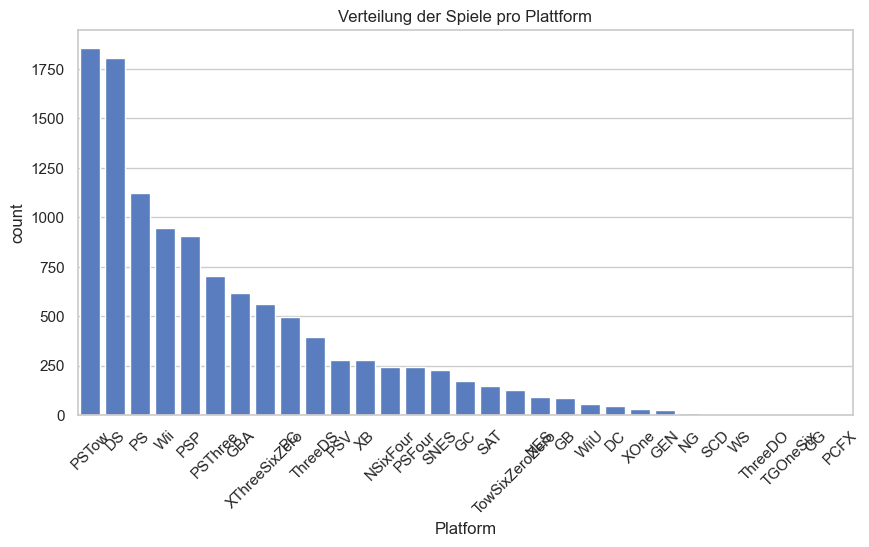

['Wii' 'NES' 'GB' 'DS' 'XThreeSixZero' 'PSThree' 'PSTow' 'SNES' 'GBA'
 'ThreeDS' 'PSFour' 'NSixFour' 'PS' 'XB' 'PC' 'TowSixZeroZero' 'PSP' 'GC'
 'WiiU' 'GEN' 'XOne' 'DC' 'SAT' 'PSV' 'SCD' 'WS' 'NG' 'TGOneSix' 'ThreeDO'
 'GG' 'PCFX']


In [4]:
# --- 5. Analyse der Kategorien (Platform) ---
n_unique_platforms = df['Platform'].nunique()
print(f"Anzahl der einzigartigen Plattformen: {n_unique_platforms}")

# Profi-Tipp: Häufigkeitsverteilung statt nur Liste
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Platform', order=df['Platform'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Verteilung der Spiele pro Plattform")

# Speichern des ersten Outputs im neuen Ordner
plt.savefig(os.path.join(OUTPUT_DIR, "platform_distribution.png"), bbox_inches='tight')
plt.show()

# Die Liste der Plattformen für die Dokumentation
print(df['Platform'].unique())

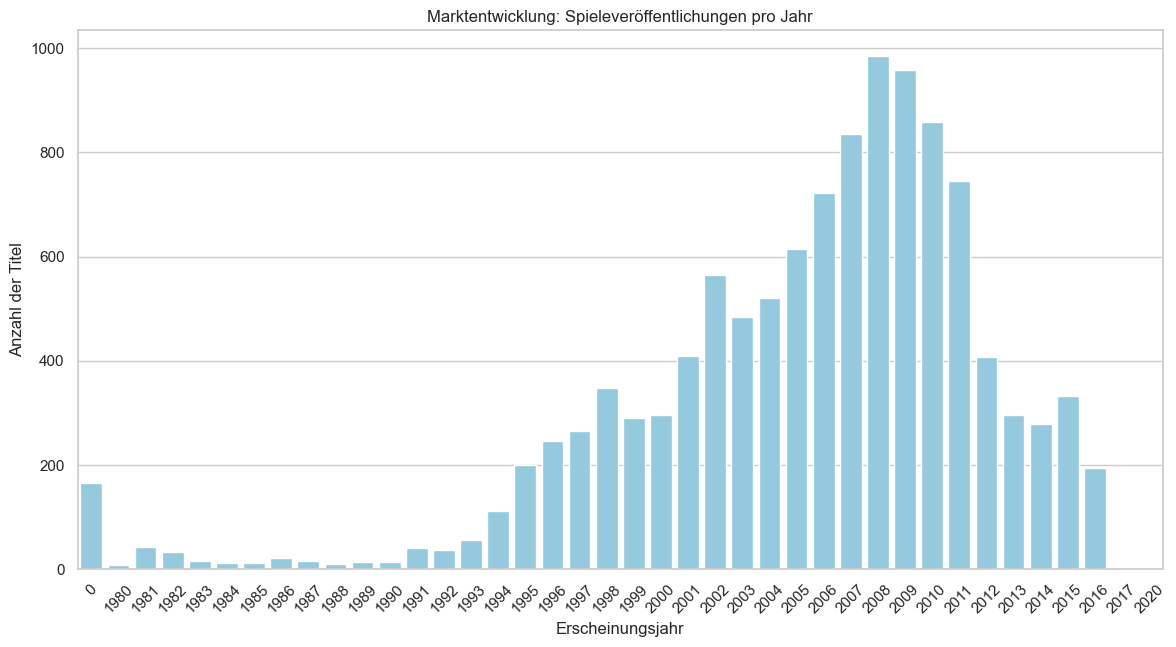

✅ Grafik gespeichert unter: 00_Outputs\games_per_year_plot.png
✅ Statistik gespeichert unter: 00_Outputs\games_per_year_stats.txt


In [7]:
# Pfade für die Outputs definieren
YEAR_PLOT_PATH = os.path.join("00_Outputs", "games_per_year_plot.png")
YEAR_STATS_PATH = os.path.join("00_Outputs", "games_per_year_stats.txt")

if 'Year' in df.columns:
    # 1. Daten aggregieren
    # Wir zählen die Spiele pro Jahr und sortieren sie chronologisch
    jahr_counts = df['Year'].value_counts().sort_index()

    # 2. Statistik-Export (Textdatei)
    with open(YEAR_STATS_PATH, "w", encoding="utf-8") as f:
        f.write("--- Anzahl der Spieleveröffentlichungen pro Jahr ---\n")
        f.write(jahr_counts.to_string())
    
    # 3. Visualisierung (mit Seaborn für professionellen Look)
    plt.figure(figsize=(14, 7))
    sns.barplot(x=jahr_counts.index.astype(int), y=jahr_counts.values, color='skyblue')
    
    # Formatierung verbessern
    plt.xticks(rotation=45)
    plt.xlabel("Erscheinungsjahr")
    plt.ylabel("Anzahl der Titel")
    plt.title("Marktentwicklung: Spieleveröffentlichungen pro Jahr")
    
    # Grafik speichern, bevor plt.show() sie aus dem Cache löscht
    plt.savefig(YEAR_PLOT_PATH, bbox_inches='tight', dpi=300)
    plt.show()

    print(f"✅ Grafik gespeichert unter: {YEAR_PLOT_PATH}")
    print(f"✅ Statistik gespeichert unter: {YEAR_STATS_PATH}")

else:
    print("⚠️ Spalte 'Year' nicht gefunden. Analyse übersprungen.")

Akt 2: Die Entdeckung – "Muster im Nebel" (Blöcke 6–10)
Jetzt kommen die ersten Visualisierungen. Hier suchst du nach den "Helden" (Plattformen).

Die Story: "Hardware ist der Herzschlag der Branche. Wir sehen den Aufstieg und Fall von Imperien wie Sony, Nintendo und Microsoft."

Einbau: Nutze vor dem interaktiven Plotly-Dashboard (Block 10): „Statische Bilder reichen nicht. Tauchen wir interaktiv ab: Welche Konsole hat wann das Ruder übernommen? Hier wird die Geschichte lebendig.“

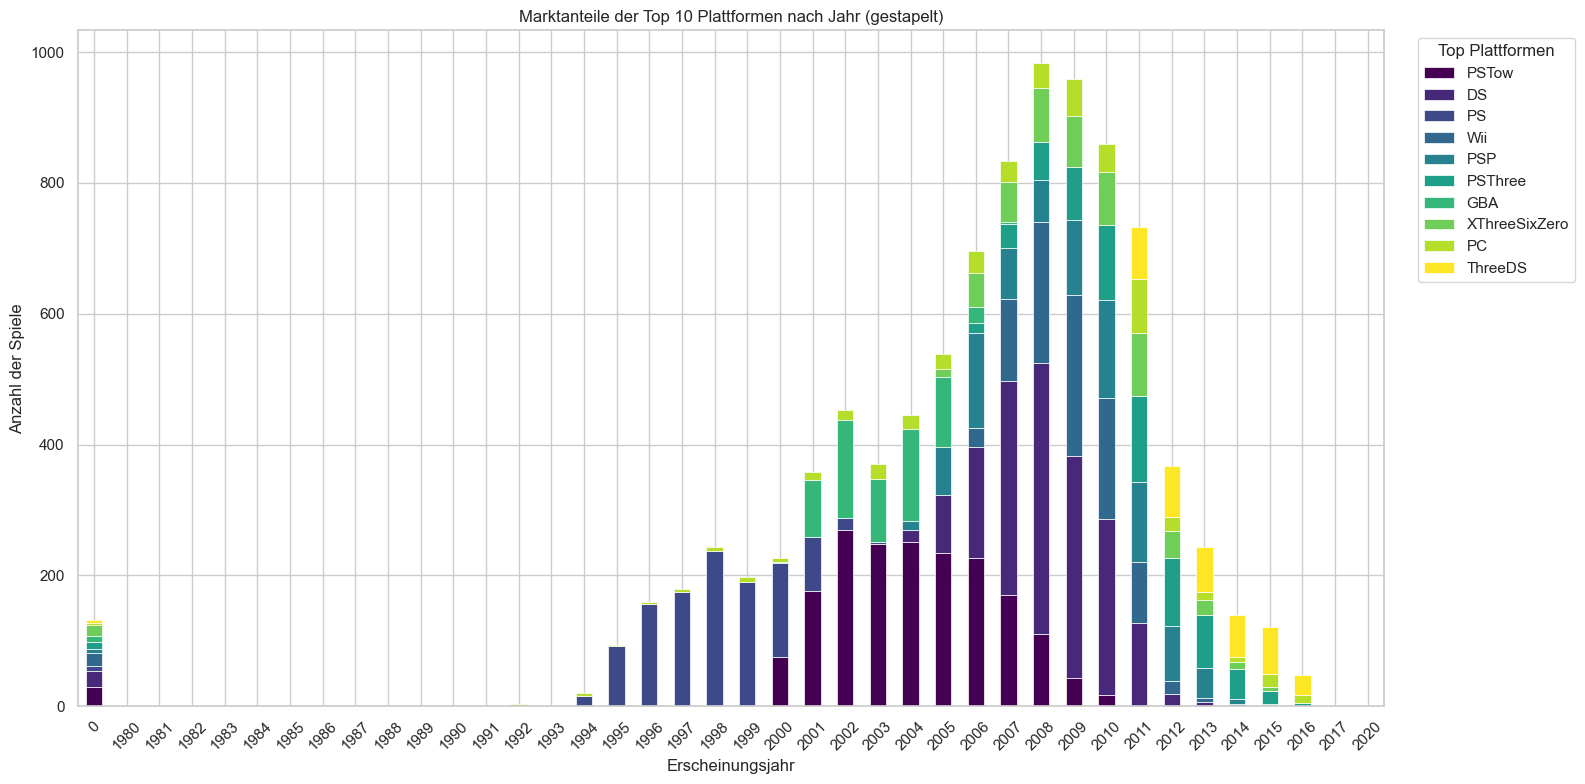

✅ Trend-Grafik gespeichert unter: 00_Outputs\platform_trends_per_year.png
✅ Matrix-Daten (Top 10) gespeichert unter: 00_Outputs\platform_trends_matrix.csv


In [8]:
# Pfade für die Outputs
PLATFORM_TREND_PLOT = os.path.join("00_Outputs", "platform_trends_per_year.png")
PLATFORM_TREND_DATA = os.path.join("00_Outputs", "platform_trends_matrix.csv")

if {'Year', 'Platform'}.issubset(df.columns):
    # 1. Daten aggregieren (Pivot-Tabelle)
    # Wir nutzen size() und unstack(), um eine Matrix zu erstellen
    platform_year_matrix = df.groupby(['Year', 'Platform']).size().unstack(fill_value=0)
    
    # Profi-Tipp: Da 30+ Plattformen das Chart sprengen, konzentrieren wir uns auf die Top 10
    top_platforms = df['Platform'].value_counts().nlargest(10).index
    filtered_matrix = platform_year_matrix[top_platforms]

    # 2. Daten-Export (CSV ist hier besser als TXT, da es eine große Matrix ist)
    filtered_matrix.to_csv(PLATFORM_TREND_DATA)

    # 3. Visualisierung
    # Wir nutzen eine etwas größere Figur und ein sauberes Farbschema
    ax = filtered_matrix.plot(kind='bar', 
                              stacked=True, 
                              figsize=(16, 8), 
                              colormap='viridis', # 'viridis' ist besser für die Farbwahrnehmung
                              edgecolor='white', 
                              linewidth=0.5)

    # Formatierung der Achsen
    plt.xticks(rotation=45)
    plt.xlabel("Erscheinungsjahr")
    plt.ylabel("Anzahl der Spiele")
    plt.title("Marktanteile der Top 10 Plattformen nach Jahr (gestapelt)")
    
    # Legende außerhalb platzieren
    plt.legend(title="Top Plattformen", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Speichern und Layout optimieren
    plt.tight_layout()
    plt.savefig(PLATFORM_TREND_PLOT, dpi=300)
    plt.show()

    print(f"✅ Trend-Grafik gespeichert unter: {PLATFORM_TREND_PLOT}")
    print(f"✅ Matrix-Daten (Top 10) gespeichert unter: {PLATFORM_TREND_DATA}")

else:
    print("⚠️ Benötigte Spalten fehlen für die Trend-Analyse.")

In [9]:
# Pfade für die Dokumentation der Korrekturen
CLEANING_LOG = os.path.join("00_Outputs", "data_cleaning_log.txt")

# 1. Identifikation & Export der Fehler (Block 9)
# Wir suchen nach 0 oder NaN
mask_invalid_year = (df['Year'] == 0) | (df['Year'].isna())
invalid_entries = df[mask_invalid_year].copy()

with open(CLEANING_LOG, "w", encoding="utf-8") as f:
    f.write(f"--- Bereinigungs-Log: Spalte 'Year' ---\n")
    f.write(f"Anzahl fehlerhafter Einträge gefunden: {len(invalid_entries)}\n\n")
    f.write(invalid_entries[['Name', 'Platform', 'Year']].to_string())

# 2. Effiziente Imputation (Block 10)
# Zuerst 0 durch NaN ersetzen, damit Pandas-Funktionen greifen
df['Year'] = df['Year'].replace(0, np.nan)

# Profi-Weg: transform() statt apply()
# Wir gruppieren nach Plattform und füllen NaNs mit dem Modus der jeweiligen Gruppe
# Der Modus kann mehrere Werte liefern, daher nehmen wir mit [0] den ersten.
df['Year'] = df.groupby('Platform')['Year'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# 3. Ergebnis-Check
remaining_nans = df['Year'].isna().sum()
print(f"✅ Imputation abgeschlossen. Verbleibende NaNs in 'Year': {remaining_nans}")

with open(CLEANING_LOG, "a", encoding="utf-8") as f:
    f.write(f"\n\nNach der Imputation verbleibende NaNs: {remaining_nans}")

✅ Imputation abgeschlossen. Verbleibende NaNs in 'Year': 0


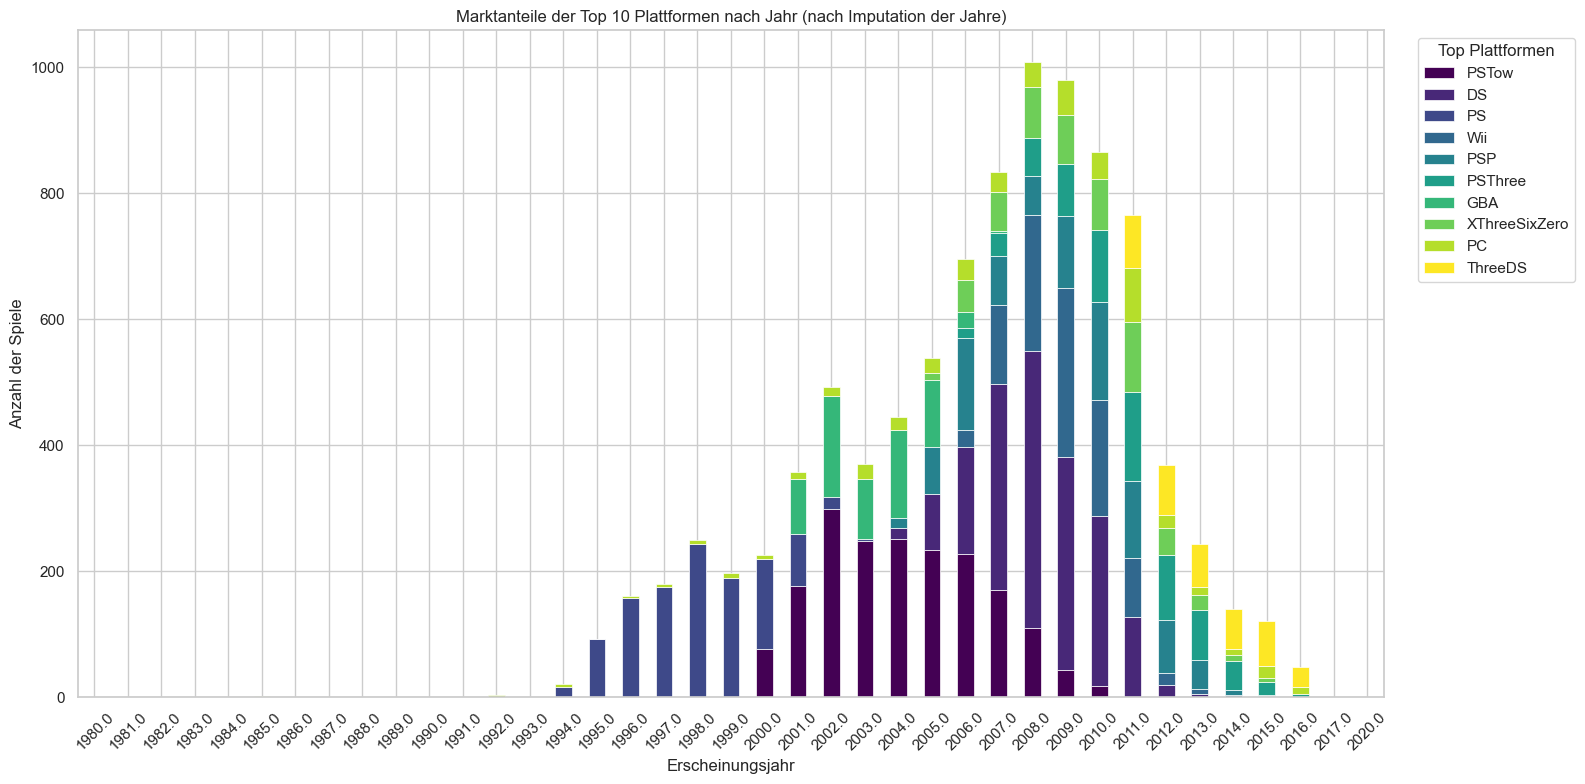

✅ Bereinigte Grafik gespeichert unter: 00_Outputs\platform_trends_per_year_CLEANED.png
✅ Bereinigte Matrix-Daten (Top 10) gespeichert unter: 00_Outputs\platform_trends_matrix_CLEANED.csv


In [10]:
# Pfade für die neuen Outputs definieren (Konsistente Benennung)
PLATFORM_TREND_CLEANED_PLOT = os.path.join("00_Outputs", "platform_trends_per_year_CLEANED.png")
PLATFORM_TREND_CLEANED_DATA = os.path.join("00_Outputs", "platform_trends_matrix_CLEANED.csv")

if {'Year', 'Platform'}.issubset(df.columns):
    # 1. Daten aggregieren (genau wie in Block 8)
    # Wichtig: 'df' ist nun die bereinigte Arbeitskopie
    platform_year_matrix_cleaned = df.groupby(['Year', 'Platform']).size().unstack(fill_value=0)
    
    # 2. Konsistenz-Check: Wir nutzen die GLEICHEN Top 10 Plattformen wie in Block 8
    # top_platforms wurde bereits in Block 8 definiert. Falls nicht, definieren wir sie hier neu.
    try:
        filtered_matrix_cleaned = platform_year_matrix_cleaned[top_platforms]
    except NameError:
         top_platforms = df['Platform'].value_counts().nlargest(10).index
         filtered_matrix_cleaned = platform_year_matrix_cleaned[top_platforms]

    # 3. Daten-Export (CSV)
    filtered_matrix_cleaned.to_csv(PLATFORM_TREND_CLEANED_DATA)

    # 4. Visualisierung (Exakt gleicher Stil wie in Block 8 für Vergleichbarkeit)
    ax = filtered_matrix_cleaned.plot(kind='bar', 
                                      stacked=True, 
                                      figsize=(16, 8), 
                                      colormap='viridis', # Gleiche Colormap wie Block 8
                                      edgecolor='white', 
                                      linewidth=0.5)

    # Formatierung der Achsen
    plt.xticks(rotation=45)
    plt.xlabel("Erscheinungsjahr")
    plt.ylabel("Anzahl der Spiele")
    
    # Titel anpassen: Zeigt, dass dies der bereinigte Stand ist
    plt.title("Marktanteile der Top 10 Plattformen nach Jahr (nach Imputation der Jahre)")
    
    # Legende außerhalb platzieren
    plt.legend(title="Top Plattformen", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Speichern und Layout optimieren
    plt.tight_layout()
    plt.savefig(PLATFORM_TREND_CLEANED_PLOT, dpi=300)
    plt.show()

    print(f"✅ Bereinigte Grafik gespeichert unter: {PLATFORM_TREND_CLEANED_PLOT}")
    print(f"✅ Bereinigte Matrix-Daten (Top 10) gespeichert unter: {PLATFORM_TREND_CLEANED_DATA}")

else:
    print("⚠️ Benötigte Spalten fehlen für die bereinigte Trend-Analyse.")

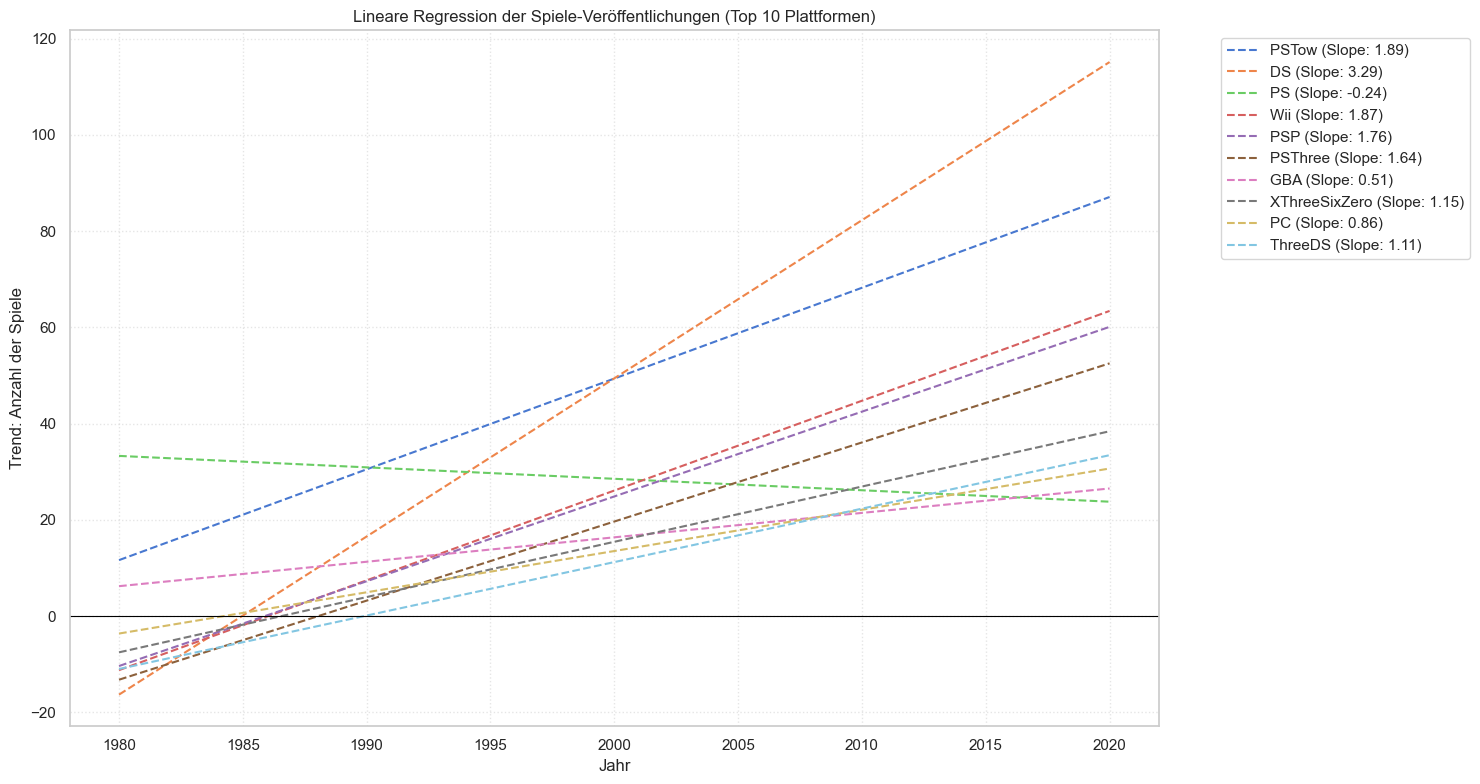

✅ Trend-Koeffizienten gespeichert: 00_Outputs\platform_trend_coefficients.csv
✅ Trend-Grafik gespeichert: 00_Outputs\platform_trends_regression.png

Plattformen mit dem stärksten Wachstum/Rückgang:


,Platform,Slope (Trend),Intercept
1,DS,3.287007,-6524.612664
0,PSTow,1.886866,-3724.376997
3,Wii,1.866449,-3706.820397
4,PSP,1.762315,-3499.778762
5,PSThree,1.643828,-3268.018828


In [11]:
# Pfade für die Trend-Ergebnisse
TREND_STATS_PATH = os.path.join("00_Outputs", "platform_trend_coefficients.csv")
TREND_PLOT_PATH = os.path.join("00_Outputs", "platform_trends_regression.png")

if {'Year', 'Platform'}.issubset(df.columns):
    # 1. Daten vorbereiten (Matrix: Jahre als Zeilen, Plattformen als Spalten)
    matrix = df.groupby(['Year', 'Platform']).size().unstack(fill_value=0)
    x = matrix.index.values.astype(int)
    
    trend_results = []
    plt.figure(figsize=(15, 8))

    # Wir konzentrieren uns auf die Top-Plattformen aus Block 8/11 für die Grafik
    # (Sonst wird das Bild zu unruhig)
    for plat in top_platforms:
        y = matrix[plat].values
        
        # Lineare Regression: y = m*x + b
        # m = Steigung (Trend), b = Schnittpunkt
        m, b = np.polyfit(x, y, 1)
        
        # Ergebnisse für die Tabelle speichern
        trend_results.append({'Platform': plat, 'Slope (Trend)': m, 'Intercept': b})
        
        # Trendlinie plotten
        plt.plot(x, m*x + b, label=f"{plat} (Slope: {m:.2f})", linestyle='--')

    # 2. Styling & Dokumentation
    plt.axhline(0, color='black', linewidth=0.8, linestyle='-') # Nulllinie zur Orientierung
    plt.xlabel("Jahr")
    plt.ylabel("Trend: Anzahl der Spiele")
    plt.title("Lineare Regression der Spiele-Veröffentlichungen (Top 10 Plattformen)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    
    # Export der Koeffizienten als CSV
    trend_df = pd.DataFrame(trend_results).sort_values(by='Slope (Trend)', ascending=False)
    trend_df.to_csv(TREND_STATS_PATH, index=False)

    # Speichern der Grafik
    plt.tight_layout()
    plt.savefig(TREND_PLOT_PATH, dpi=300)
    plt.show()

    print(f"✅ Trend-Koeffizienten gespeichert: {TREND_STATS_PATH}")
    print(f"✅ Trend-Grafik gespeichert: {TREND_PLOT_PATH}")
    
    # Kurze Vorschau der stärksten Trends
    print("\nPlattformen mit dem stärksten Wachstum/Rückgang:")
    display(trend_df.head())

else:
    print("⚠️ Benötigte Spalten fehlen für die Regressions-Analyse.")

In [12]:
import plotly.express as px
import plotly.io as pio

# Pfad für den interaktiven Export
HTML_OUTPUT_PATH = os.path.join("00_Outputs", "interactive_platform_trends.html")

if {'Year', 'Platform'}.issubset(df.columns):
    # 1. Daten aggregieren
    # Wir nutzen unser bereinigtes 'df'
    platform_year_counts = df.groupby(['Year', 'Platform']).size().reset_index(name='Anzahl Spiele')

    # 2. Interaktiven Plot erstellen
    fig = px.line(
        platform_year_counts,
        x="Year",
        y="Anzahl Spiele",
        color="Platform",
        title="Interaktive Analyse: Spiele-Veröffentlichungen pro Plattform",
        labels={"Year": "Erscheinungsjahr", "Anzahl Spiele": "Veröffentlichte Titel"},
        template="plotly_white" # Ein sauberer, professioneller Look
    )

    # Optimierung: Linien glätten und Marker hinzufügen
    fig.update_traces(mode="lines+markers", marker=dict(size=4))
    
    # Layout-Anpassungen für bessere Lesbarkeit
    fig.update_layout(
        hovermode="x unified", # Zeigt alle Werte eines Jahres gleichzeitig beim Drüberfahren
        legend_title_text='Plattformen',
        xaxis=dict(tickmode='linear', dtick=5) # Alle 5 Jahre eine Beschriftung
    )

    # 3. Export als interaktive HTML-Datei
    # Das ist dein "Asset": Diese Datei kann jeder im Browser öffnen, ohne Python zu haben!
    fig.write_html(HTML_OUTPUT_PATH)
    
    # Anzeige im Notebook (Renderer auf 'notebook' oder 'inline' stellen)
    fig.show()

    print(f"✅ Interaktives Dashboard gespeichert unter: {HTML_OUTPUT_PATH}")

else:
    print("⚠️ Spalten für Plotly-Analyse nicht gefunden.")

✅ Interaktives Dashboard gespeichert unter: 00_Outputs\interactive_platform_trends.html


Akt 3: Die Analyse – "Die Anatomie des Erfolgs" (Blöcke 11–17)
Hier gehst du in die Tiefe. Es geht um Geld und Vorlieben.

Die Story: "Es reicht nicht zu wissen, dass gespielt wird. Wir müssen wissen: Wo wird das Geld ausgegeben und für welche Genres? Ist ein Hit in Japan auch ein Hit in den USA?"

Einbau: Nutze die Genre-Analyse (Block 12): „Genres sind Modeerscheinungen. Wir beobachten den Shift von Platformern (Super Mario Ära) zu Action-Giganten. Wer den Zeitgeist nicht trifft, verliert Marktanteile.“

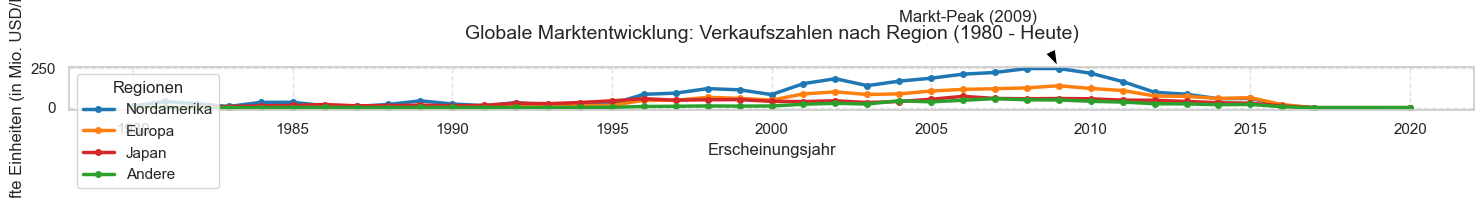

✅ Regionale Verkaufsstatistik gespeichert: 00_Outputs\regional_sales_per_year.csv


In [13]:
# Pfade für die Verkaufsanalyse
SALES_TREND_PLOT = os.path.join("00_Outputs", "regional_sales_trends.png")
SALES_STATS_CSV = os.path.join("00_Outputs", "regional_sales_per_year.csv")

# 1. Daten aggregieren
# Wir nutzen unser bereinigtes 'df' (mit den imputierten Jahren!)
sales_columns = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

if all(col in df.columns for col in sales_columns + ["Year"]):
    region_year = df.groupby("Year")[sales_columns].sum()
    
    # Export der aggregierten Daten als CSV
    region_year.to_csv(SALES_STATS_CSV)

    # 2. Visualisierung (Professionalisierung des Plots)
    plt.figure(figsize=(15, 8))
    
    # Wir nutzen eine Stacked-Area-Plot Logik (optional, aber sehr aussagekräftig)
    # Oder wir bleiben bei Linien, machen sie aber dicker und schöner:
    colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c'] # Blau (NA), Orange (EU), Rot (JP), Grün (Other)
    
    region_year.plot(kind='line', 
                     figsize=(15, 7), 
                     linewidth=2.5, 
                     marker='o', 
                     markersize=4,
                     color=colors,
                     ax=plt.gca()) # Nutzt die aktuelle Achse

    # 3. Styling & Beschriftung
    plt.title("Globale Marktentwicklung: Verkaufszahlen nach Region (1980 - Heute)", fontsize=14, pad=20)
    plt.ylabel("Verkaufte Einheiten (in Mio. USD/Einheiten)", fontsize=12)
    plt.xlabel("Erscheinungsjahr", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Regionen", labels=["Nordamerika", "Europa", "Japan", "Andere"], loc='upper left')

    # Fokus-Highlight: Den Peak des Marktes markieren
    total_sales_per_year = region_year.sum(axis=1)
    peak_year = total_sales_per_year.idxmax()
    peak_value = total_sales_per_year.max()
    
    plt.annotate(f'Markt-Peak ({int(peak_year)})', 
                 xy=(peak_year, region_year.loc[peak_year].max()), 
                 xytext=(peak_year-5, peak_value+50),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

    # Speichern
    plt.tight_layout()
    plt.savefig(SALES_TREND_PLOT, dpi=300)
    plt.show()

    print(f"✅ Regionale Verkaufsstatistik gespeichert: {SALES_STATS_CSV}")

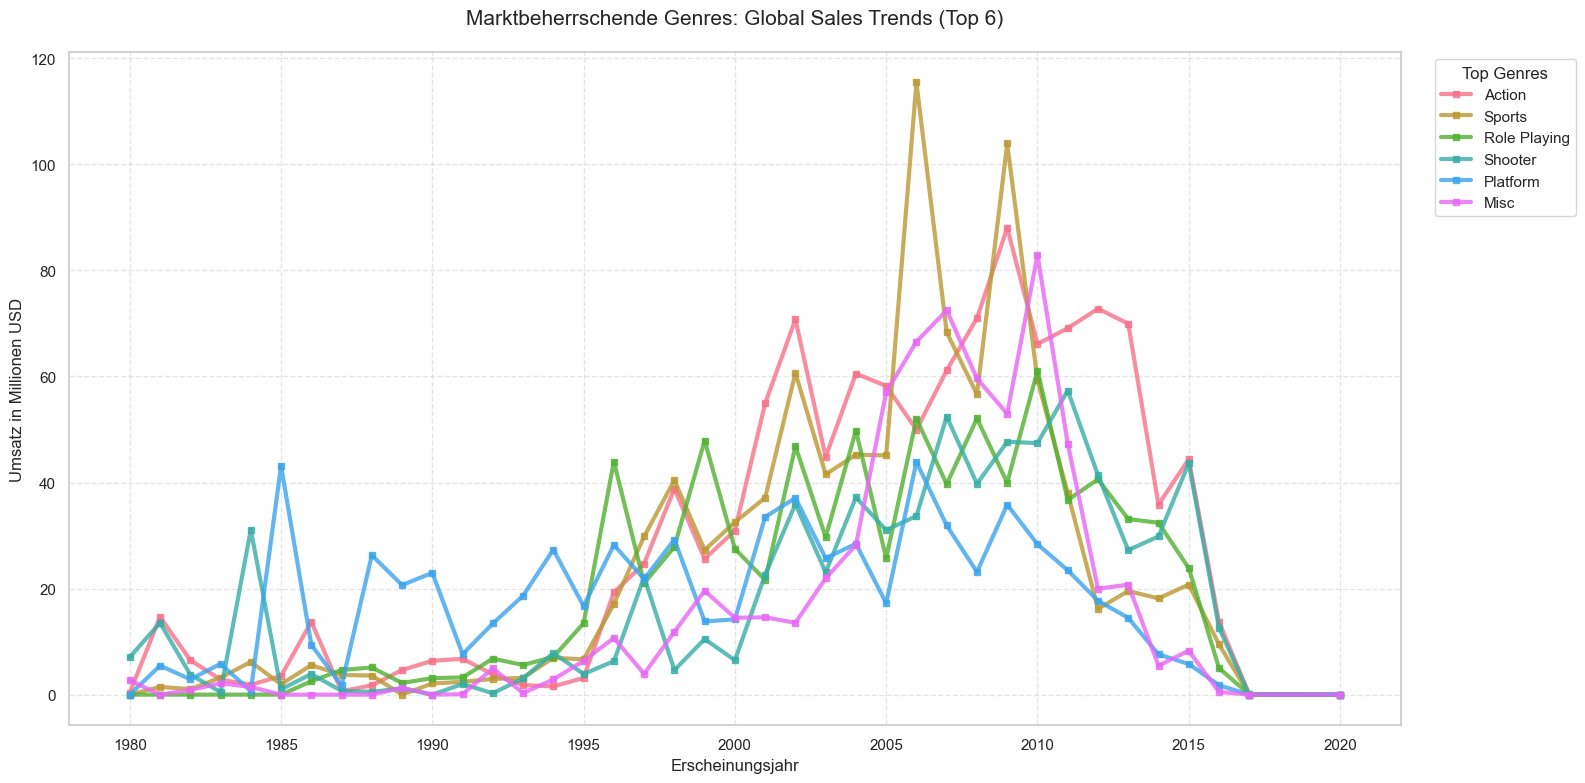

✅ Genre-Umsatzmatrix gespeichert: 00_Outputs\genre_sales_per_year.csv
✅ Genre-Trendgrafik gespeichert: 00_Outputs\genre_sales_trends.png


In [14]:
# Pfade für die Genre-Analyse
GENRE_TREND_PLOT = os.path.join("00_Outputs", "genre_sales_trends.png")
GENRE_MATRIX_CSV = os.path.join("00_Outputs", "genre_sales_per_year.csv")

if {'Year', 'Genre', 'Global_Sales'}.issubset(df.columns):
    # 1. Daten aggregieren
    genre_year = df.groupby(["Year", "Genre"])["Global_Sales"].sum().unstack(fill_value=0)
    
    # Export der kompletten Matrix
    genre_year.to_csv(GENRE_MATRIX_CSV)

    # Profi-Filter: Nur die Top 6 Genres (nach Gesamtumsatz) für den Plot
    # Das reduziert das Rauschen und hebt die wichtigsten Trends hervor
    top_genres = df.groupby("Genre")["Global_Sales"].sum().nlargest(6).index
    filtered_genre_year = genre_year[top_genres]

    # 2. Visualisierung
    plt.figure(figsize=(16, 8))
    
    # Wir nutzen eine qualitative Farbpalette von Seaborn
    colors = sns.color_palette("husl", len(top_genres))
    
    filtered_genre_year.plot(kind='line', 
                             ax=plt.gca(), 
                             linewidth=3, 
                             marker='s', # Quadratische Marker
                             markersize=4,
                             alpha=0.8,
                             color=colors)

    # 3. Styling & Finetuning
    plt.title("Marktbeherrschende Genres: Global Sales Trends (Top 6)", fontsize=15, pad=20)
    plt.ylabel("Umsatz in Millionen USD", fontsize=12)
    plt.xlabel("Erscheinungsjahr", fontsize=12)
    plt.grid(True, which='major', linestyle='--', alpha=0.5)
    
    # Legende optimieren
    plt.legend(title="Top Genres", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

    # Speichern
    plt.tight_layout()
    plt.savefig(GENRE_TREND_PLOT, dpi=300)
    plt.show()

    print(f"✅ Genre-Umsatzmatrix gespeichert: {GENRE_MATRIX_CSV}")
    print(f"✅ Genre-Trendgrafik gespeichert: {GENRE_TREND_PLOT}")

else:
    print("⚠️ Benötigte Spalten für Genre-Analyse fehlen.")

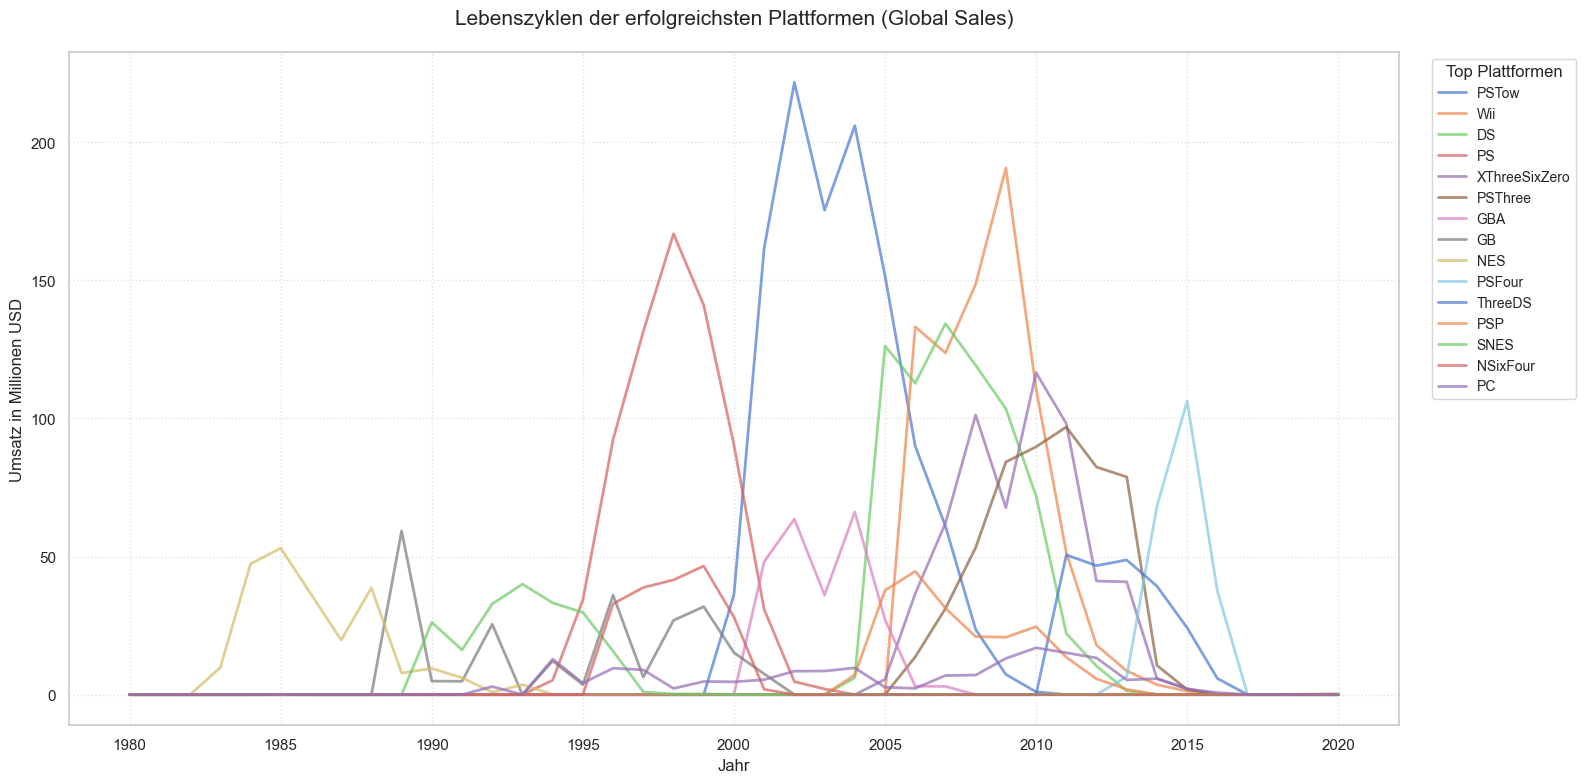

✅ Lebenszyklus-Grafik gespeichert: 00_Outputs\platform_lifecycles.png
✅ Peak-Statistiken gespeichert: 00_Outputs\platform_lifecycle_stats.csv


In [15]:
# Pfade für die Lebenszyklus-Analyse
LIFECYCLE_PLOT = os.path.join("00_Outputs", "platform_lifecycles.png")
LIFECYCLE_STATS = os.path.join("00_Outputs", "platform_lifecycle_stats.csv")

if {'Year', 'Platform', 'Global_Sales'}.issubset(df.columns):
    # 1. Daten aggregieren
    platform_year_sales = df.groupby(["Year", "Platform"])["Global_Sales"].sum().unstack(fill_value=0)
    
    # 2. Top-Plattformen identifizieren (um das Chaos zu begrenzen)
    # Wir nehmen die Top 15 Plattformen der gesamten Geschichte für die Legende
    top_15_all_time = df.groupby("Platform")["Global_Sales"].sum().nlargest(15).index
    filtered_lifecycle = platform_year_sales[top_15_all_time]

    # 3. Statistik-Export: Wann war der Peak jeder Plattform?
    peak_stats = []
    for col in filtered_lifecycle.columns:
        peak_year = filtered_lifecycle[col].idxmax()
        peak_sales = filtered_lifecycle[col].max()
        total_lifespan = df[df['Platform'] == col]['Year'].max() - df[df['Platform'] == col]['Year'].min()
        peak_stats.append({
            'Platform': col, 
            'Peak_Year': peak_year, 
            'Peak_Sales': peak_sales,
            'Lifespan_Years': total_lifespan
        })
    
    pd.DataFrame(peak_stats).to_csv(LIFECYCLE_STATS, index=False)

    # 4. Visualisierung (Professionalisierung)
    plt.figure(figsize=(16, 8))
    
    # Wir nutzen ein Flächen-Diagramm (Area Plot) ohne Stapelung (overlap)
    # Das sieht bei Lebenszyklen oft moderner aus
    filtered_lifecycle.plot(kind='line', 
                            ax=plt.gca(), 
                            linewidth=2, 
                            alpha=0.7)

    # 5. Styling
    plt.title("Lebenszyklen der erfolgreichsten Plattformen (Global Sales)", fontsize=15, pad=20)
    plt.ylabel("Umsatz in Millionen USD", fontsize=12)
    plt.xlabel("Jahr", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Legende dezent platzieren
    plt.legend(title="Top Plattformen", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small', ncol=1)

    # Speichern
    plt.tight_layout()
    plt.savefig(LIFECYCLE_PLOT, dpi=300)
    plt.show()

    print(f"✅ Lebenszyklus-Grafik gespeichert: {LIFECYCLE_PLOT}")
    print(f"✅ Peak-Statistiken gespeichert: {LIFECYCLE_STATS}")

else:
    print("⚠️ Benötigte Spalten für Lebenszyklus-Analyse fehlen.")

C:\Users\kasum\AppData\Local\Temp\ipykernel_20456\1161560257.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




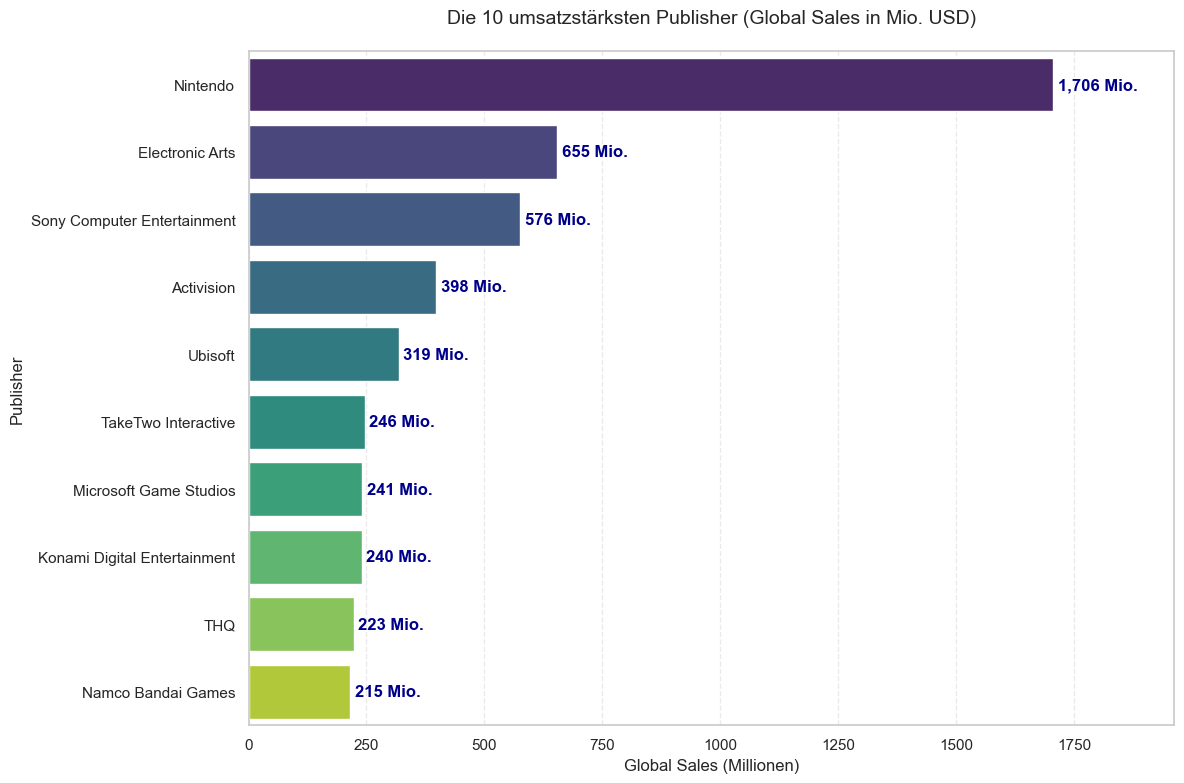

✅ Top Publisher Grafik gespeichert: 00_Outputs\top_10_publishers.png
✅ Top Publisher Statistik gespeichert: 00_Outputs\top_10_publishers_stats.csv


In [16]:
# Pfade für die Publisher-Analyse
PUB_PLOT_PATH = os.path.join("00_Outputs", "top_10_publishers.png")
PUB_CSV_PATH = os.path.join("00_Outputs", "top_10_publishers_stats.csv")

if {'Publisher', 'Global_Sales'}.issubset(df.columns):
    # 1. Daten aggregieren & Top 10 ermitteln
    top_pub = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(10)
    
    # Export der Top 10 als CSV
    top_pub.to_csv(PUB_CSV_PATH)

    # 2. Visualisierung (Horizontaler Balken für bessere Lesbarkeit)
    plt.figure(figsize=(12, 8))
    # Wir nutzen eine Farbverlaufspalette von Seaborn
    ax = sns.barplot(x=top_pub.values, y=top_pub.index, palette="viridis")

    # 3. Profi-Feature: Zahlenwerte an die Balken schreiben
    for i, v in enumerate(top_pub.values):
        ax.text(v + 10, i, f'{v:,.0f} Mio.', va='center', fontweight='bold', color='darkblue')

    # Styling
    plt.title("Die 10 umsatzstärksten Publisher (Global Sales in Mio. USD)", fontsize=14, pad=20)
    plt.xlabel("Global Sales (Millionen)", fontsize=12)
    plt.ylabel("Publisher", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.4)

    # X-Achse etwas erweitern, damit die Beschriftung Platz hat
    plt.xlim(0, top_pub.max() * 1.15)

    # Speichern
    plt.tight_layout()
    plt.savefig(PUB_PLOT_PATH, dpi=300)
    plt.show()

    print(f"✅ Top Publisher Grafik gespeichert: {PUB_PLOT_PATH}")
    print(f"✅ Top Publisher Statistik gespeichert: {PUB_CSV_PATH}")

else:
    print("⚠️ Spalten für Publisher-Analyse nicht gefunden.")

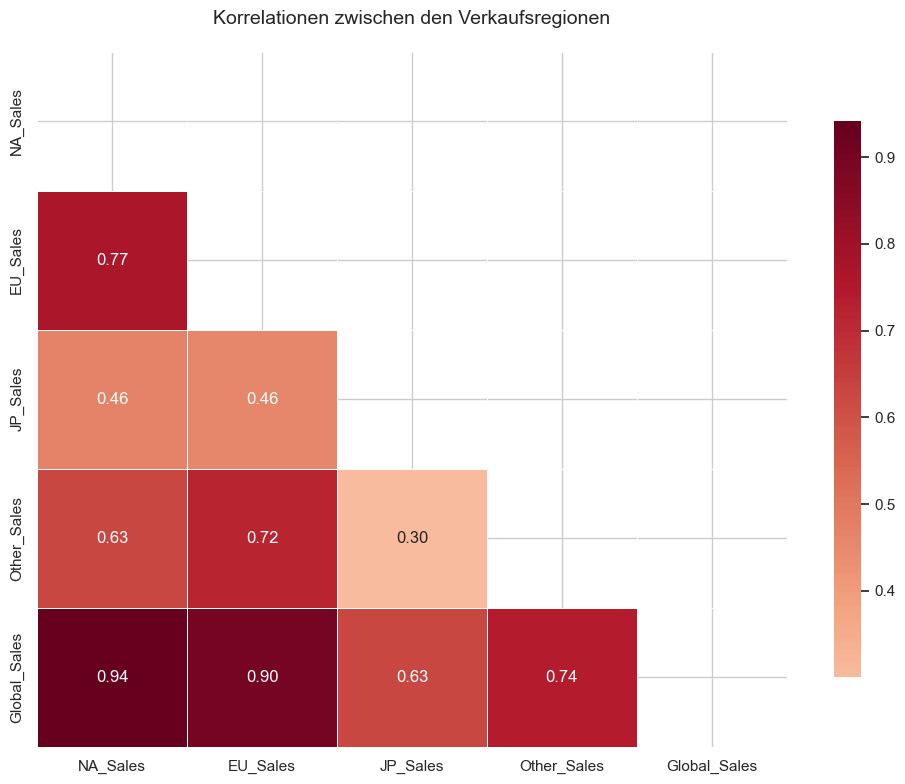

✅ Korrelations-Matrix gespeichert: 00_Outputs\sales_correlation_matrix.csv
✅ Heatmap gespeichert: 00_Outputs\sales_correlation_heatmap.png

Einfluss auf die Global Sales (Korrelationsfaktor):
NA_Sales       0.941409
EU_Sales       0.902898
Other_Sales    0.740456
JP_Sales       0.629525
Name: Global_Sales, dtype: float64


In [17]:
# Pfade für die Korrelations-Analyse
CORR_PLOT_PATH = os.path.join("00_Outputs", "sales_correlation_heatmap.png")
CORR_MATRIX_PATH = os.path.join("00_Outputs", "sales_correlation_matrix.csv")

# 1. Korrelation berechnen
sales_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]
if all(col in df.columns for col in sales_cols):
    corr = df[sales_cols].corr()
    
    # Export der Matrix als CSV
    corr.to_csv(CORR_MATRIX_PATH)

    # 2. Maske für die obere Hälfte erstellen (optional, aber Profi-Look)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # 3. Visualisierung
    plt.figure(figsize=(10, 8))
    
    # Heatmap mit Maske und schöner Formatierung
    sns.heatmap(corr, 
                mask=mask, 
                annot=True, 
                fmt=".2f", # Zwei Nachkommastellen
                cmap="RdBu_r", # Rot-Blau (Rot = Positiv, Blau = Negativ)
                center=0, 
                linewidths=.5, 
                cbar_kws={"shrink": .8})

    plt.title("Korrelationen zwischen den Verkaufsregionen", fontsize=14, pad=20)
    
    # Speichern
    plt.tight_layout()
    plt.savefig(CORR_PLOT_PATH, dpi=300)
    plt.show()

    print(f"✅ Korrelations-Matrix gespeichert: {CORR_MATRIX_PATH}")
    print(f"✅ Heatmap gespeichert: {CORR_PLOT_PATH}")

    # Ein kleiner Bonus-Check: Welche Region korreliert am stärksten mit Global_Sales?
    top_corr = corr['Global_Sales'].sort_values(ascending=False)
    print("\nEinfluss auf die Global Sales (Korrelationsfaktor):")
    print(top_corr[1:]) # Wir lassen Global_Sales vs Global_Sales (1.0) weg

else:
    print("⚠️ Sales-Spalten für Korrelationsanalyse fehlen.")

In [18]:
# Pfad für die finale Pivot-Tabelle
PIVOT_DATA_PATH = os.path.join("00_Outputs", "market_matrix_year_plat_genre.csv")

if {'Year', 'Platform', 'Genre'}.issubset(df.columns):
    # 1. Erstellen der Pivot-Tabelle
    # Wir nutzen count(), um die Anzahl der Spiele pro Segment zu erhalten
    market_pivot = df.groupby(["Year", "Platform", "Genre"]).size().reset_index(name="Game_Count")
    
    # 2. Sortierung für bessere Analyse (Neueste Jahre zuerst)
    market_pivot = market_pivot.sort_values(by=["Year", "Game_Count"], ascending=[False, False])

    # 3. Export der Matrix
    # Diese Datei ist perfekt für Excel-Pivot-Tabellen oder BI-Tools
    market_pivot.to_csv(PIVOT_DATA_PATH, index=False)

    # 4. Deep Dive: Top-Nischen-Check (Beispiel für den Recruiter)
    # Was war im aktuellsten Jahr des Datensatzes die stärkste Kombination?
    latest_year = market_pivot['Year'].max()
    top_niche = market_pivot[market_pivot['Year'] == latest_year].head(3)

    print(f"✅ Markt-Matrix gespeichert unter: {PIVOT_DATA_PATH}")
    print(f"\n--- Top 3 Segmente im Jahr {int(latest_year)} ---")
    display(top_niche)

else:
    print("⚠️ Benötigte Spalten für die Pivot-Tabelle fehlen.")

✅ Markt-Matrix gespeichert unter: 00_Outputs\market_matrix_year_plat_genre.csv

--- Top 3 Segmente im Jahr 2020 ---


,Year,Platform,Genre,Game_Count
1596,2020.0,DS,Simulation,1


In [ ]:
# Pfad für die Verkaufs-Matrix
SALES_MATRIX_PATH = os.path.join("00_Outputs", "global_sales_pivot_matrix.csv")

if {'Year', 'Platform', 'Global_Sales'}.issubset(df.columns):
    # 1. Erstellen der Pivot Table
    # Wir summieren die Global_Sales pro Jahr und Plattform
    sales_pivot = pd.pivot_table(
        df, 
        values="Global_Sales", 
        index="Year", 
        columns="Platform", 
        aggfunc="sum", 
        fill_value=0
    )

    # 2. Export der Matrix
    sales_pivot.to_csv(SALES_MATRIX_PATH)

    # 3. "Styling" für das Notebook (Highlighting der Top-Werte)
    # Das macht die Tabelle im Notebook interaktiv lesbar wie eine Heatmap
    styled_pivot = sales_pivot.tail(10).style.background_gradient(cmap='YlOrRd', axis=None)
    
    print(f"✅ Sales-Matrix (Wide-Format) gespeichert: {SALES_MATRIX_PATH}")
    print("\n--- Analyse der letzten 10 Jahre (Umsatz-Heatmap) ---")
    display(styled_pivot)

else:
    print("⚠️ Spalten für die Sales-Pivot-Tabelle fehlen.")

✅ Sales-Matrix (Wide-Format) gespeichert: 00_Outputs\global_sales_pivot_matrix.csv

--- Analyse der letzten 10 Jahre (Umsatz-Heatmap) ---


Platform,DC,DS,GB,GBA,GC,GEN,GG,NES,NG,NSixFour,PC,PCFX,PS,PSFour,PSP,PSThree,PSTow,PSV,SAT,SCD,SNES,TGOneSix,ThreeDO,ThreeDS,TowSixZeroZero,WS,Wii,WiiU,XB,XOne,XThreeSixZero
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2009.000000,0.000000,103.510000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.120000,0.000000,0.000000,0.000000,20.780000,84.250000,7.310000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,190.670000,0.000000,0.000000,0.000000,67.690000
2010.000000,0.000000,71.930000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.950000,0.000000,0.000000,0.000000,24.620000,89.730000,1.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,110.750000,0.000000,0.000000,0.000000,116.550000
2011.000000,0.000000,22.140000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.160000,0.000000,0.000000,0.000000,13.530000,96.880000,0.020000,4.640000,0.000000,0.000000,0.000000,0.000000,0.000000,50.600000,0.000000,0.000000,51.370000,0.000000,0.000000,0.000000,98.120000
2012.000000,0.000000,10.370000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.280000,0.000000,0.000000,0.000000,5.720000,82.390000,0.000000,11.660000,0.000000,0.000000,0.000000,0.000000,0.000000,46.680000,0.000000,0.000000,17.890000,11.890000,0.000000,0.000000,41.140000
2013.000000,0.000000,1.360000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.320000,0.000000,0.000000,6.520000,1.910000,78.820000,0.000000,7.200000,0.000000,0.000000,0.000000,0.000000,0.000000,48.760000,0.000000,0.000000,8.610000,12.080000,0.000000,5.670000,40.850000
2014.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.790000,0.000000,0.000000,68.210000,0.090000,10.570000,0.000000,6.700000,0.000000,0.000000,0.000000,0.000000,0.000000,39.280000,0.000000,0.000000,3.600000,13.370000,0.000000,9.810000,5.830000
2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,106.300000,0.100000,1.850000,0.000000,5.590000,0.000000,0.000000,0.000000,0.000000,0.000000,24.210000,0.000000,0.000000,1.260000,13.900000,0.000000,11.810000,2.200000
2016.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.750000,0.000000,0.000000,37.550000,0.000000,0.120000,0.000000,2.220000,0.000000,0.000000,0.000000,0.000000,0.000000,5.850000,0.000000,0.000000,0.000000,2.220000,0.000000,1.050000,0.000000
2017.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Akt 4: Das Finale – "Die mathematische Wahrheit" (Blöcke 18–22)
Der Höhepunkt. Hier beweist du deine Thesen mit Statistik.

Die Story: "Bauchgefühl ist gut, Statistik ist besser. Wir beweisen die Dominanz des US-Marktes und entlarven die Illusion, dass früher alles kleiner war."

Einbau: Direkt vor der Signifikanz-Prüfung (Block 20): „Ist unser Erfolg nur Zufall? Wir unterziehen unsere Thesen dem wissenschaftlichen Kreuzverhör (p-Wert). Erst wenn die Mathematik 'Ja' sagt, ist unsere Story wasserdicht.“

In [24]:
# Prüfen, ob pivot_table existiert, sonst erstellen wir sie kurz neu
if 'pivot_table' not in locals():
    print("🔄 'pivot_table' war nicht definiert, erstelle sie neu...")
    pivot_table = pd.pivot_table(
        df, 
        values="Global_Sales", 
        index="Year", 
        columns="Platform", 
        aggfunc="sum", 
        fill_value=0
    )

# --- Ab hier dein gewohnter Code ---
# 1. Stichproben-Validierung
print("--- Stichprobe der Pivot-Tabelle (20 zufällige Jahre/Einträge) ---")
display(pivot_table.sample(min(20, len(pivot_table))))

# 2. Ranking
print("\n--- All-Time Sales Ranking pro Plattform (in Mio. USD) ---")
platform_ranking = pivot_table.sum().sort_values(ascending=False)
display(platform_ranking.head(10))

# 3. Korrelation r (NA vs Global)
# Wir nutzen 'df', da dieses sicher aus Block 2 vorhanden ist
r_na_global = df["NA_Sales"].corr(df["Global_Sales"])
print(f"\n--- Statistische Korrelation ---")
print(f"Korrelationskoeffizient (r) zwischen NA-Sales und Global-Sales: {r_na_global:.3f}")

# 4. Finaler Export
PIVOT_EXPORT_PATH = os.path.join("00_Outputs", "pivot_platform_year_FINAL.csv")
pivot_table.to_csv(PIVOT_EXPORT_PATH)
print(f"\n✅ Finale Pivot-Tabelle gespeichert unter: {PIVOT_EXPORT_PATH}")

🔄 'pivot_table' war nicht definiert, erstelle sie neu...
--- Stichprobe der Pivot-Tabelle (20 zufällige Jahre/Einträge) ---


Platform,DC,DS,GB,GBA,GC,GEN,GG,NES,NG,NSixFour,...,TGOneSix,ThreeDO,ThreeDS,TowSixZeroZero,WS,Wii,WiiU,XB,XOne,XThreeSixZero
Year,,,,,,,,,,,,,,,,,,,,,
1993.0,0.00,0.00,0.00,0.00,0.00,0.50,0.00,3.61,0.14,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1997.0,0.00,0.00,6.37,0.00,0.00,0.00,0.00,0.00,0.00,38.78,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2002.0,0.29,0.00,0.00,63.56,32.01,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,20.04,0.00,0.00
1992.0,0.00,0.00,25.48,0.00,0.00,9.99,0.04,0.86,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1985.0,0.00,0.02,0.00,0.00,0.00,0.00,0.00,53.03,0.00,0.00,...,0.0,0.00,0.00,0.45,0.00,0.00,0.00,0.00,0.00,0.00
2001.0,0.92,0.00,7.51,48.15,22.07,0.00,0.00,0.00,0.00,1.91,...,0.0,0.00,0.00,0.00,0.03,0.00,0.00,17.46,0.00,0.00
1994.0,0.00,0.00,12.17,0.00,0.00,5.36,0.00,0.11,0.80,0.00,...,0.0,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2000.0,3.59,0.00,15.21,0.06,0.00,0.00,0.00,0.00,0.00,28.09,...,0.0,0.00,0.00,0.00,0.17,0.00,0.00,0.99,0.00,0.00
1999.0,4.75,0.00,31.86,0.00,0.00,0.00,0.00,0.00,0.00,46.56,...,0.0,0.00,0.00,0.00,0.46,0.00,0.00,0.00,0.00,0.00



--- All-Time Sales Ranking pro Plattform (in Mio. USD) ---


Platform
PSTow            1135.44
Wii               789.67
DS                708.26
PS                699.34
XThreeSixZero     577.82
PSThree           542.68
GBA               247.13
GB                234.11
NES               233.08
PSFour            218.61
dtype: float64


--- Statistische Korrelation ---
Korrelationskoeffizient (r) zwischen NA-Sales und Global-Sales: 0.941

✅ Finale Pivot-Tabelle gespeichert unter: 00_Outputs\pivot_platform_year_FINAL.csv


In [25]:
# Berechnung des Pearson-Korrelationskoeffizienten (r)
# Wir nutzen 'df' (unsere bereinigte Kopie)
r = df["NA_Sales"].corr(df["Global_Sales"])

print(f"--- Statistische Analyse: Markt-Abhängigkeit ---")
print(f"Korrelationskoeffizient (r) zwischen NA_Sales und Global_Sales: {r:.4f}")

# Statistische Einordnung
if r > 0.9:
    print("Ergebnis: Extrem starke positive Korrelation. Der nordamerikanische Markt ist der Haupttreiber für den globalen Erfolg.")
elif r > 0.7:
    print("Ergebnis: Starke positive Korrelation. Erfolge in NA spiegeln sich meist global wider.")
else:
    print("Ergebnis: Moderate Korrelation. Andere Märkte haben einen gewichtigen Anteil am Gesamtergebnis.")

--- Statistische Analyse: Markt-Abhängigkeit ---
Korrelationskoeffizient (r) zwischen NA_Sales und Global_Sales: 0.9414
Ergebnis: Extrem starke positive Korrelation. Der nordamerikanische Markt ist der Haupttreiber für den globalen Erfolg.


In [26]:
from scipy.stats import pearsonr

# 1. Präzise Berechnung von r und p
# Wir nutzen wieder 'df' für die konsistente Analyse
if {'NA_Sales', 'Global_Sales'}.issubset(df.columns):
    r, p = pearsonr(df["NA_Sales"], df["Global_Sales"])

    print("--- Statistische Signifikanz-Prüfung (NA vs Global) ---")
    print(f"Korrelationskoeffizient (r): {r:.4f}")
    print(f"p-Wert: {p:.4e}") # Wissenschaftliche Notation für extrem kleine Werte

    if p < 0.05:
        print("✅ Ergebnis ist statistisch signifikant (p < 0.05).")
    else:
        print("⚠️ Ergebnis ist statistisch nicht signifikant.")

# 2. Validierung der Summen-Logik
# Wir prüfen, ob Global_Sales wirklich die Summe der Regionen ist
expected_global = df["NA_Sales"] + df["EU_Sales"] + df["JP_Sales"] + df["Other_Sales"]
# Wir erlauben eine kleine Toleranz wegen Rundungsfehlern (0.01)
diff = (df["Global_Sales"] - expected_global).abs()
error_count = (diff > 0.02).sum()

print(f"\n--- Daten-Integritäts-Check ---")
if error_count == 0:
    print("✅ Global_Sales entspricht exakt der Summe aller Regionen.")
else:
    print(f"ℹ️ Hinweis: Bei {error_count} Zeilen gibt es leichte Abweichungen (Rundungsdifferenzen).")

--- Statistische Signifikanz-Prüfung (NA vs Global) ---
Korrelationskoeffizient (r): 0.9414
p-Wert: 0.0000e+00
✅ Ergebnis ist statistisch signifikant (p < 0.05).

--- Daten-Integritäts-Check ---
ℹ️ Hinweis: Bei 4 Zeilen gibt es leichte Abweichungen (Rundungsdifferenzen).


--- Korrelations-Analyse: Zeit vs. Umsatz ---
Pearson-r (Year zu Global_Sales): -0.0778


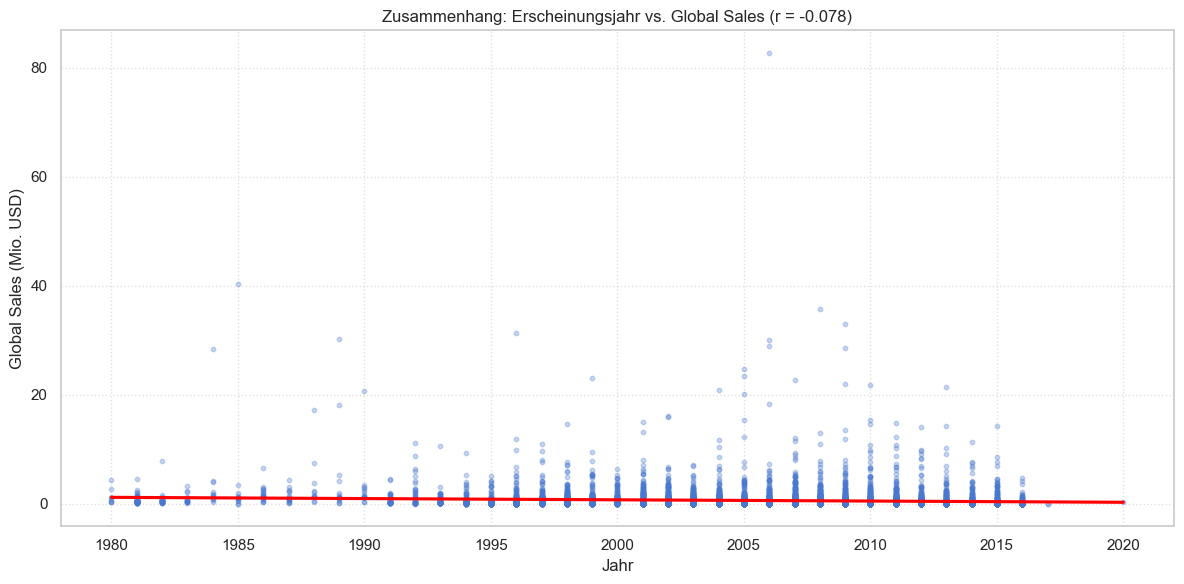


Interpretation: Nahezu keine lineare Korrelation.
Das bedeutet: Ein späteres Erscheinungsjahr garantiert keinen höheren Umsatz pro Spiel.


In [27]:
# Pfad für den Korrelations-Plot
YEAR_SALES_CORR_PLOT = os.path.join("00_Outputs", "year_vs_sales_correlation.png")

if {'Year', 'Global_Sales'}.issubset(df.columns):
    # 1. Korrelation berechnen
    # Wir nutzen 'df' (bereinigt)
    corr_year_sales = df[["Year", "Global_Sales"]].corr().iloc[0, 1]
    
    print(f"--- Korrelations-Analyse: Zeit vs. Umsatz ---")
    print(f"Pearson-r (Year zu Global_Sales): {corr_year_sales:.4f}")

    # 2. Visualisierung: Warum ist der Wert so, wie er ist?
    plt.figure(figsize=(12, 6))
    
    # Ein Regplot zeigt die Punkte UND die Regressionslinie mit Vertrauensintervall
    sns.regplot(data=df, x="Year", y="Global_Sales", 
                scatter_kws={'alpha':0.3, 's':10}, 
                line_kws={'color':'red'})

    plt.title(f"Zusammenhang: Erscheinungsjahr vs. Global Sales (r = {corr_year_sales:.3f})")
    plt.xlabel("Jahr")
    plt.ylabel("Global Sales (Mio. USD)")
    plt.grid(True, linestyle=':', alpha=0.6)

    # 3. Export
    plt.tight_layout()
    plt.savefig(YEAR_SALES_CORR_PLOT, dpi=300)
    plt.show()

    # Interpretation für dein Portfolio
    if abs(corr_year_sales) < 0.1:
        print("\nInterpretation: Nahezu keine lineare Korrelation.")
        print("Das bedeutet: Ein späteres Erscheinungsjahr garantiert keinen höheren Umsatz pro Spiel.")
    else:
        print("\nInterpretation: Es besteht ein messbarer linearer Trend.")

else:
    print("⚠️ Spalten 'Year' oder 'Global_Sales' fehlen.")

--- Analyse des globalen Marktwachstums ---
Korrelation zwischen Jahr und Gesamtumsatz: 0.5167
Interpretation: Moderates Wachstum mit Schwankungen (evtl. Konsolenzyklen sichtbar).


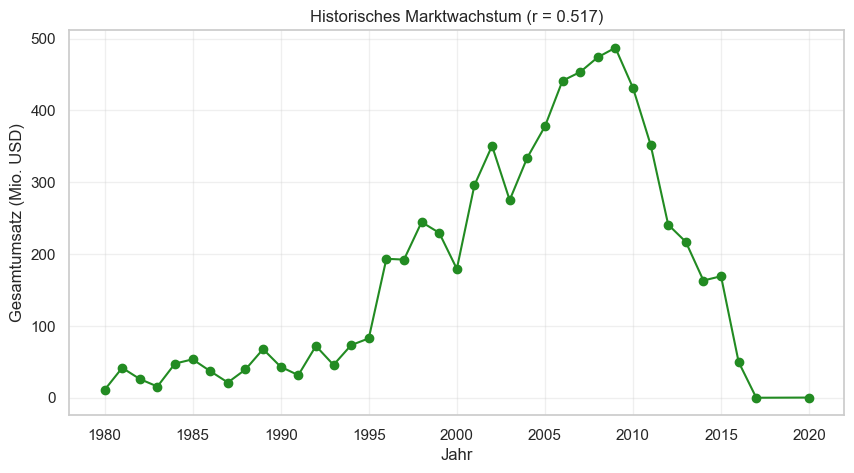

In [28]:
# 1. Aggregation der Daten pro Jahr
yearly_sales = df.groupby("Year")["Global_Sales"].sum()
years = df.groupby("Year")["Year"].mean() # Erzeugt eine passende Zeitreihe

# 2. Korrelation berechnen
market_growth_corr = yearly_sales.corr(years)

print("--- Analyse des globalen Marktwachstums ---")
print(f"Korrelation zwischen Jahr und Gesamtumsatz: {market_growth_corr:.4f}")

# 3. Einordnung des Ergebnisses
if market_growth_corr > 0.8:
    print("Interpretation: Starke lineare Expansion. Der Gesamtmarkt ist über die Zeit hinweg fast stetig gewachsen.")
elif market_growth_corr > 0.5:
    print("Interpretation: Moderates Wachstum mit Schwankungen (evtl. Konsolenzyklen sichtbar).")
else:
    print("Interpretation: Kein klarer linearer Trend beim Gesamtumsatz erkennbar.")

# Optional: Ein kleiner Plot, um dieses "Wachstum" zu zeigen
plt.figure(figsize=(10, 5))
plt.plot(years, yearly_sales, marker='o', color='forestgreen', label="Global Sales Summe")
plt.title(f"Historisches Marktwachstum (r = {market_growth_corr:.3f})")
plt.xlabel("Jahr")
plt.ylabel("Gesamtumsatz (Mio. USD)")
plt.grid(alpha=0.3)
plt.show()